
Component 1
Fraction of total variance explained by this component:0.6240
Total fraction of variance explained by the first 1 component(s): 0.6240

Component 2
Fraction of total variance explained by this component:0.3760
Total fraction of variance explained by the first 2 component(s): 1.0000


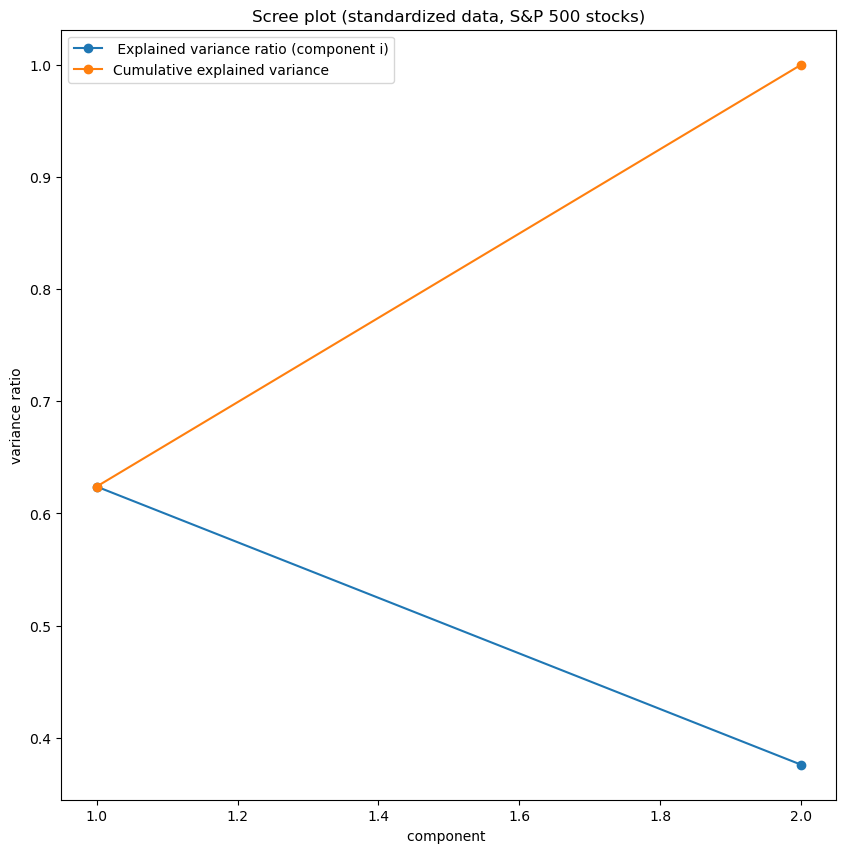

In [1]:
import sys, os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

import numpy.random as rand
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from data.BaseDataHandler import BaseDataHandler
from Function1DataHandler import Function1DataHandler
from sklearn.preprocessing import StandardScaler

#Load the data
func_data = Function1DataHandler()
func_data.add_weekly_updates()
data = func_data.get_inputs()

scaler = StandardScaler().fit(data)

data_scaled = scaler.transform(data)

#Number of component guards (optional but safer)
n_comp = min(10, data_scaled.shape[1])
pca_scaled = PCA(n_comp).fit(data_scaled)
var_scaled = pca_scaled.explained_variance_ratio_
var_scaled_explained = np.cumsum(var_scaled)

#Print the scaled values you just computed
for i in range(n_comp):
    print(
            f"\nComponent {i+1}"
            f"\nFraction of total variance explained by this component:{var_scaled[i]:.4f}"
            f"\nTotal fraction of variance explained by the first {i+1} component(s): {var_scaled_explained[i]:.4f}"
        )
#Plot using the scaled arrays for both series and axis length
plt.figure(figsize=(10, 10))
plt.plot(range(1, n_comp+1), var_scaled, marker="o", label=" Explained variance ratio (component i)")
plt.plot(range(1, n_comp+1), var_scaled_explained, marker="o", label="Cumulative explained variance")
plt.xlabel("component ")
plt.ylabel("variance ratio")
plt.title("Scree plot (standardized data, S&P 500 stocks)")
plt.legend()
plt.show()